<a href="https://colab.research.google.com/github/Nikesh5005/ML_PROJ/blob/main/modal_training_DT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pickle

with open('/content/drive/MyDrive/train_test_val_data/X_train_DT.pkl', 'rb') as f:
    X_train = pickle.load(f)

with open('/content/drive/MyDrive/train_test_val_data/X_test_DT.pkl', 'rb') as f:
    X_test = pickle.load(f)

with open('/content/drive/MyDrive/train_test_val_data/y_train_DT.pkl', 'rb') as f:
    y_train = pickle.load(f)

with open('/content/drive/MyDrive/train_test_val_data/y_test_DT.pkl', 'rb') as f:
    y_test = pickle.load(f)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
X_test

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,Over18_Y,OverTime_No,OverTime_Yes
1041,28,866,5,3,1,1469,4,84,3,2,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
184,53,1084,13,2,1,250,4,57,4,2,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
1222,24,240,22,1,1,1714,4,58,1,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
67,45,1339,7,3,1,86,2,59,3,3,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
220,36,1396,5,2,1,304,4,62,3,2,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1047,33,430,7,3,1,1477,4,54,3,2,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
331,27,210,1,1,1,449,3,73,3,2,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
323,28,1157,2,4,1,440,1,84,1,1,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
654,39,1383,2,3,1,909,4,42,2,2,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0


In [5]:
from sklearn.tree import DecisionTreeClassifier

In [6]:
model = DecisionTreeClassifier(random_state=42)

In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [8]:
model.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [9]:
train_preds = model.predict(X_train)
train_preds

array(['No', 'No', 'Yes', ..., 'Yes', 'No', 'No'], dtype=object)

In [10]:
train_acc=accuracy_score(y_train, train_preds)
train_acc

1.0

We can make predictions and compute accuracy in one step using model.score

In [11]:
from sklearn.dummy import DummyClassifier

In [12]:
dummy_model = DummyClassifier(strategy='most_frequent')

In [13]:
dummy_model.fit(X_train, y_train)

DummyClassifier(strategy='most_frequent')

In [14]:
dummy_model.score(X_test, y_test)

0.8616780045351474

In [15]:
model.score(X_test,y_test)

0.782312925170068

In [16]:
model.feature_importances_

array([0.06142022, 0.07909049, 0.00318767, 0.00248405, 0.        ,
       0.04611307, 0.04041497, 0.06139251, 0.01459737, 0.01256594,
       0.01279442, 0.1322524 , 0.04804398, 0.00321629, 0.        ,
       0.00456943, 0.02515241, 0.        , 0.01567623, 0.04777599,
       0.01444828, 0.0174269 , 0.01378193, 0.04218581, 0.04823414,
       0.00706428, 0.02548073, 0.04423722, 0.        , 0.01298135,
       0.00456943, 0.        , 0.        , 0.00456943, 0.        ,
       0.        , 0.01012305, 0.        , 0.0015993 , 0.00606763,
       0.00971005, 0.00456943, 0.00628297, 0.        , 0.00164139,
       0.        , 0.        , 0.        , 0.00959581, 0.        ,
       0.        , 0.        , 0.        , 0.02999334, 0.        ,
       0.        , 0.07469007])

In [17]:
imp_feature_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
imp_feature_df.head(15)

,feature,importance
11,MonthlyIncome,0.132252
1,DailyRate,0.079090
56,OverTime_Yes,0.074690
0,Age,0.061420
7,HourlyRate,0.061393
24,YearsSinceLastPromotion,0.048234
12,MonthlyRate,0.048044
19,TotalWorkingYears,0.047776
5,EmployeeNumber,0.046113
27,job_change_frequency,0.044237


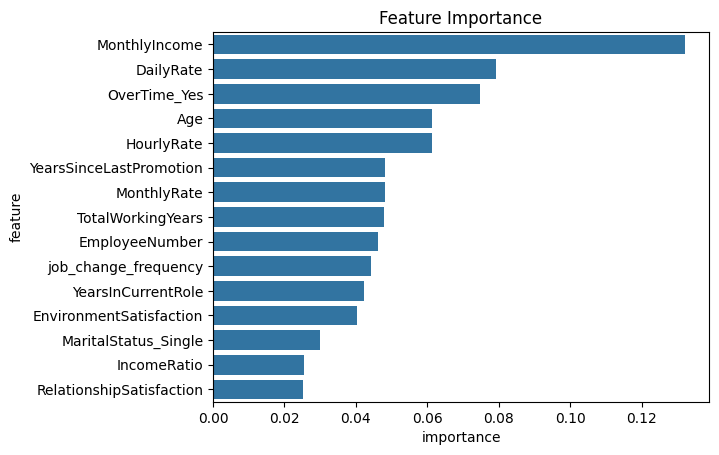

In [18]:
plt.title('Feature Importance')
sns.barplot(data=imp_feature_df.head(15), x='importance', y='feature');

In [19]:
model.get_depth()

17

## Hyperparameter tuining

In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer,f1_score

In [33]:
parameter_grid={
    'max_depth':[3, 4, 5, 6, 7, 8, 10],
    'min_samples_split':[2, 10, 20, 50],
     'min_samples_leaf':  [1, 5, 10, 20],
      'criterion':['gini', 'entropy'],
       'class_weight':['balanced', None],
       'max_features':[None, 'sqrt',0.5]
}

clf_model=DecisionTreeClassifier(ccp_alpha=0.0,random_state=42)

gride_prepruning_model=GridSearchCV(estimator=clf_model,param_grid=parameter_grid,cv=5,scoring=make_scorer(f1_score, pos_label='Yes'))
gride_prepruning_model.fit(X_train,y_train)



GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'class_weight': ['balanced', None],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 4, 5, 6, 7, 8, 10],
                         'max_features': [None, 'sqrt', 0.5],
                         'min_samples_leaf': [1, 5, 10, 20],
                         'min_samples_split': [2, 10, 20, 50]},
             scoring=make_scorer(f1_score, response_method='predict', pos_label=Yes))

In [34]:
gride_prepruning_model.best_params_

{'class_weight': 'balanced',
 'criterion': 'entropy',
 'max_depth': 4,
 'max_features': None,
 'min_samples_leaf': 10,
 'min_samples_split': 50}

In [35]:
model_first_hyper_para=DecisionTreeClassifier(
    class_weight='balanced',
    criterion='entropy',
    max_depth=4,
    max_features=None,
    min_samples_leaf=10,
    min_samples_split=50

)

In [36]:
model_first_hyper_para.fit(X_train,y_train)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=4, min_samples_leaf=10, min_samples_split=50)

In [37]:
train_pradiction=model_first_hyper_para.predict(X_train)


In [38]:
train_pradiction

array(['No', 'No', 'Yes', ..., 'Yes', 'Yes', 'Yes'], dtype=object)

In [39]:
accuracy_score(y_train,train_pradiction)

0.7210884353741497

In [40]:
model_first_hyper_para.score(X_test,y_test)

0.671201814058957

In [41]:
test_prad=model_first_hyper_para.predict(X_test)

## Model Evaluation

In [42]:
from sklearn.metrics import confusion_matrix

In [43]:
cm=confusion_matrix(y_test,test_prad)
cm

array([[255, 125],
       [ 20,  41]])

In [48]:
from sklearn.metrics import classification_report

print(classification_report(y_test, test_prad,
      target_names=['Stayed', 'Left']))

              precision    recall  f1-score   support

      Stayed       0.93      0.67      0.78       380
        Left       0.25      0.67      0.36        61

    accuracy                           0.67       441
   macro avg       0.59      0.67      0.57       441
weighted avg       0.83      0.67      0.72       441



In [47]:
sorted(np.unique(y_test))

['No', 'Yes']

The model performed as expected because it is useful for identifying who will stay, but it is unreliable for identifying who will leave.

We cannot make it much more precise, and even if we could, the model may still not be as good or accurate as expected because the target class is highly imbalanced (approximately 6:1). We need more data or a different approach, such as Random Forest, SMOTE, or threshold tuning, to improve predictions for the **Left** class.
